In [57]:
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '../..'))

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [94]:
DATA_PATH="../../data/Motor_vibration_data/land_motor_pow100.csv"
FILENAME = DATA_PATH.split("/")[-1].split(".")[0].split("_")[-1]
df = pd.read_csv(DATA_PATH)

In [95]:
df1 = df[df['device_id'] == 1].reset_index(drop=True)
df2 = df[df['device_id'] == 2].reset_index(drop=True)
df3 = df[df['device_id'] == 3].reset_index(drop=True)
df4 = df[df['device_id'] == 4].reset_index(drop=True)

# df1.to_csv('../../data/Motor_vibration_data/device_1.csv', index=True)
# df2.to_csv('../../data/Motor_vibration_data/device_2.csv', index=True)
# df3.to_csv('../../data/Motor_vibration_data/device_3.csv', index=True)
# df4.to_csv('../../data/Motor_vibration_data/device_4.csv', index=True)

In [96]:
# RMS_WINDOW_SEC=0.5
# BG    = '#0d1117'
# PANEL = '#161b22'
# GRID  = '#21262d'
# TEXT  = '#e6edf3'
# MUTED = '#8b949e'
# CX    = '#58a6ff'   # accel_x — blue
# CY    = '#3fb950'   # accel_y — green
# CZ    = '#f78166'   # accel_z — red-orange
# CMAG  = '#ffd700'

# def style_ax(ax):
#     ax.set_facecolor(PANEL)
#     ax.tick_params(colors=MUTED, labelsize=9)
#     ax.xaxis.label.set_color(MUTED)
#     ax.yaxis.label.set_color(MUTED)
#     ax.title.set_color(TEXT)
#     for sp in ax.spines.values():
#         sp.set_edgecolor(GRID)
#     ax.grid(color=GRID, linewidth=0.5, alpha=0.9)

# def style_fig(fig):
#     fig.patch.set_facecolor(BG)


# def rolling_rms(signal, window_samples):
#     result = np.zeros(len(signal))
#     for i in range(len(signal)):
#         start = max(0, i - window_samples // 2)
#         end   = min(len(signal), i + window_samples // 2)
#         result[i] = np.sqrt(np.mean(signal[start:end] ** 2))
#     return result


# def plot_rms(t, ax, ay, az, mag, fs):
#     w = max(3, int(RMS_WINDOW_SEC * fs))

#     rms_x   = rolling_rms(ax,  w)
#     rms_y   = rolling_rms(ay,  w)
#     rms_z   = rolling_rms(az,  w)
#     rms_mag = rolling_rms(mag, w)

#     fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
#     fig.suptitle(f'RMS Vibration Intensity (window = {RMS_WINDOW_SEC}s)',
#                  fontsize=13, color=TEXT, fontweight='bold')

#     for a, rms, color, label in [
#         (axes[0], rms_x,   CX,   'X RMS'),
#         (axes[1], rms_y,   CY,   'Y RMS'),
#         (axes[2], rms_z,   CZ,   'Z RMS'),
#         (axes[3], rms_mag, CMAG, 'Magnitude RMS'),
#     ]:
#         a.plot(t, rms, color=color, lw=1.0)
#         a.fill_between(t, rms, alpha=0.15, color=color)
#         a.set_ylabel(f'{label}\n(m/s²)', fontsize=8)
#         a.set_title(f'mean={np.mean(rms):.4f}  peak={np.max(rms):.4f}  '
#                     f'min={np.min(rms):.4f}',
#                     fontsize=8.5, color=MUTED)

#     axes[-1].set_xlabel('Time (s)', fontsize=10)
#     style_fig(fig)
#     [style_ax(a) for a in axes]
#     plt.tight_layout()
#     p = os.path.join(PLOT_DIR, '3_rms_over_time.png')
#     fig.savefig(p, dpi=150, bbox_inches='tight', facecolor=BG)
#     plt.close(fig)
#     print(f'  Saved: {p}')

In [97]:
def find_stationary_count(df, window=65, threshold=0.05):
    mag = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
    rolling_std = mag.rolling(window=window, min_periods=1).std()
    moving_data = df[rolling_std > threshold]
    return moving_data.index[0] if not moving_data.empty else len(df)

def plot_adjusted_rms_mag_only(dfs, fs=130.0, window_sec=0.5):
    w = max(3, int(window_sec * fs))
    
    plt.figure(figsize=(12, 4))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
    
    for i, dev_df in enumerate(dfs):
        # Detect stationary period
        stat_count = find_stationary_count(dev_df)
        
        ax_sig = dev_df['ax'].values - dev_df['ax'].iloc[:stat_count].mean()
        ay_sig = dev_df['ay'].values - dev_df['ay'].iloc[:stat_count].mean()
        az_sig = dev_df['az'].values - dev_df['az'].iloc[:stat_count].mean()
        
        mag_sig = np.sqrt(ax_sig**2 + ay_sig**2 + az_sig**2)
        rms_mag = rolling_rms(mag_sig, w)
        t = np.arange(len(ax_sig)) / fs
        dev_id = dev_df['device_id'].iloc[0]
        plt.plot(t, rms_mag, color=colors[i], lw=1.5, label=f'Device {dev_id}')

    # Formatting
    plt.title(f'Baseline-Adjusted Magnitude RMS Vibration (window = {window_sec}s)', fontweight='bold')
    plt.ylabel('Magnitude RMS (m/s²)')
    plt.xlabel('Time (s)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [98]:
# plot_adjusted_rms_mag_only([df1, df2, df3, df4], fs=130.0, window_sec=0.5)

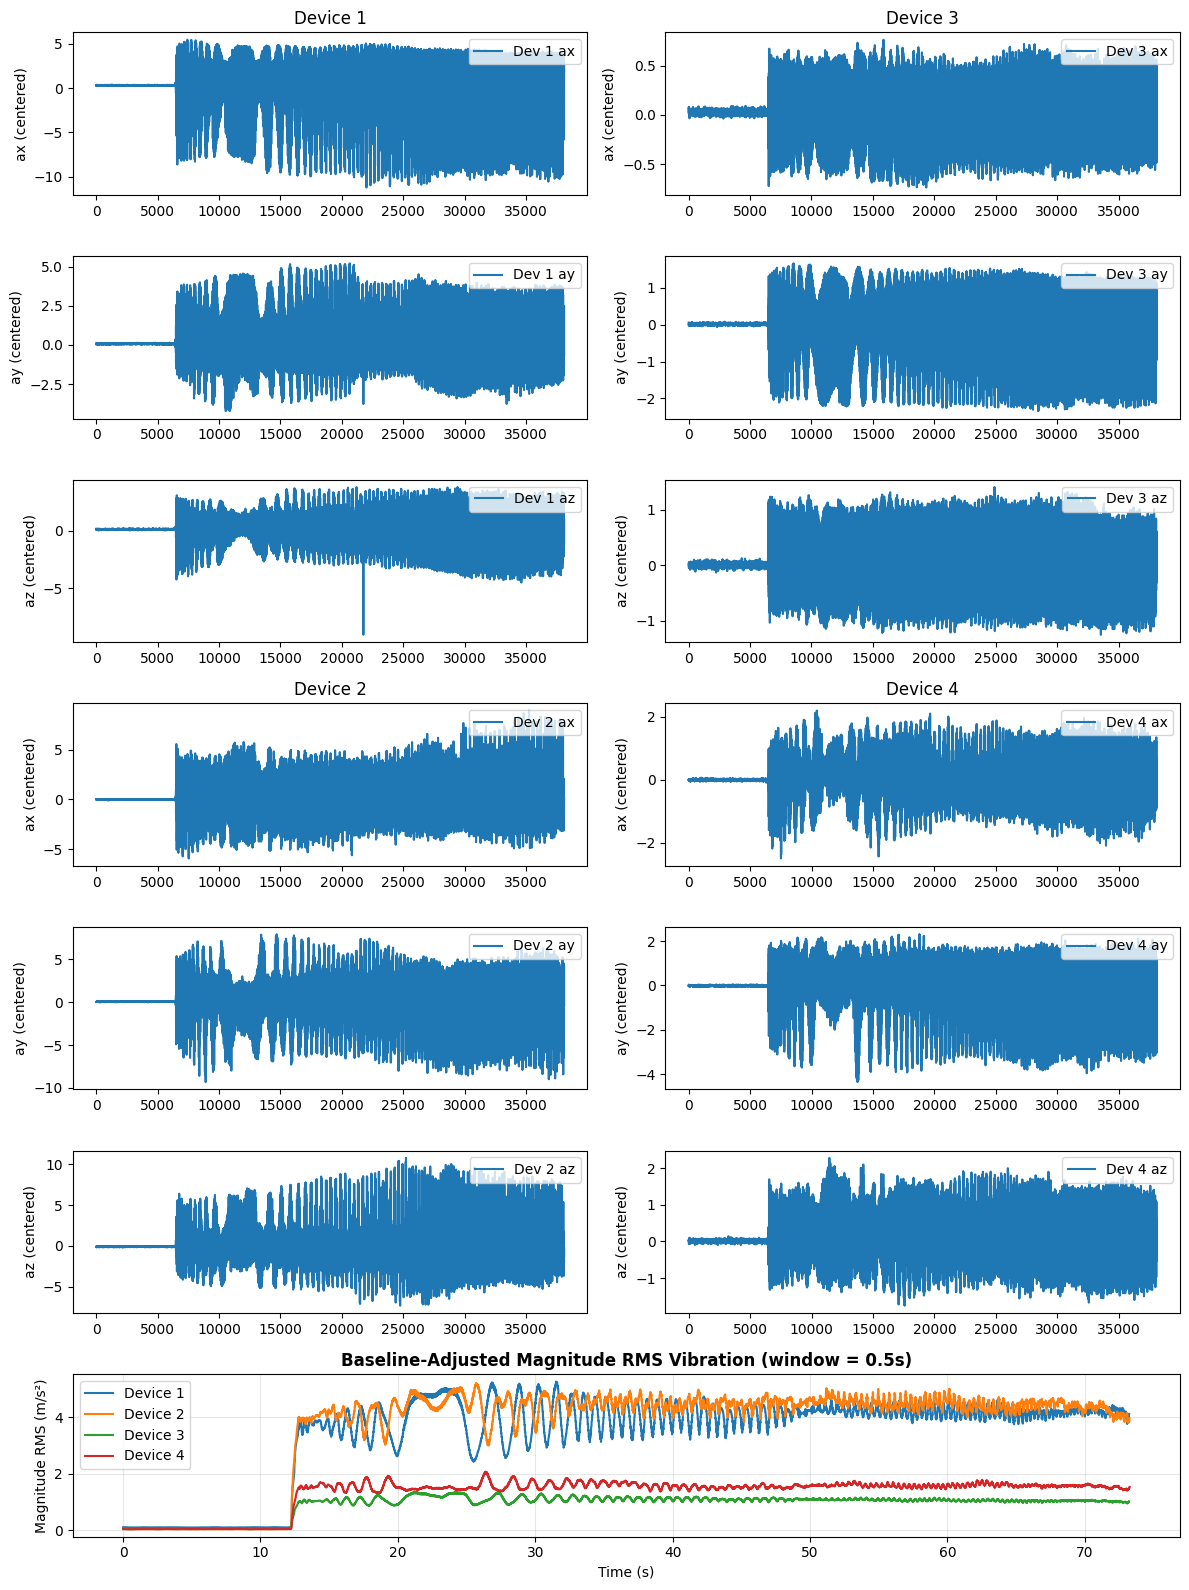

In [99]:
SAVE_PATH = "../../Simulations/IMU_motor"
fs = 130.0
window_sec = 0.5
w = max(3, int(window_sec * fs))

fig = plt.figure(figsize=(12, 16))
gs = gridspec.GridSpec(7, 2, figure=fig)

for i, dev_id in enumerate([1, 2, 3, 4]):
    col = i // 2            
    row_start = (i % 2) * 3 
    data = df[df['device_id'] == dev_id]
    
    for j, axis in enumerate(['ax', 'ay', 'az']):
        row = row_start + j
        ax = fig.add_subplot(gs[row, col])
        centered_val = data[axis] - data[axis].mean()
        ax.plot(data.index, centered_val, label=f'Dev {dev_id} {axis}')
        ax.set_ylabel(f'{axis} (centered)')
        ax.legend(loc='upper right')
        
        if j == 0:
            ax.set_title(f'Device {dev_id}')

ax_rms = fig.add_subplot(gs[6, :]) 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, dev_id in enumerate([1, 2, 3, 4]):
    dev_df = df[df['device_id'] == dev_id].reset_index(drop=True)
    
    stat_count = find_stationary_count(dev_df)
    ax_sig = dev_df['ax'].values - dev_df['ax'].iloc[:stat_count].mean()
    ay_sig = dev_df['ay'].values - dev_df['ay'].iloc[:stat_count].mean()
    az_sig = dev_df['az'].values - dev_df['az'].iloc[:stat_count].mean()
    
    mag_sig = np.sqrt(ax_sig**2 + ay_sig**2 + az_sig**2)
    rms_mag = rolling_rms(mag_sig, w)
    
    t = np.arange(len(ax_sig)) / fs
    ax_rms.plot(t, rms_mag, color=colors[i], lw=1.5, label=f'Device {dev_id}')

ax_rms.set_title(f'Baseline-Adjusted Magnitude RMS Vibration (window = {window_sec}s)', fontweight='bold')
ax_rms.set_ylabel('Magnitude RMS (m/s²)')
ax_rms.set_xlabel('Time (s)')
ax_rms.legend()
ax_rms.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(f"{SAVE_PATH}/{FILENAME}", bbox_inches='tight')
plt.show()